In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer  # For handling missing values (optional)
import matplotlib.pyplot as plt


In [2]:
if __name__ == "__main__":
    data_path = r"C:\Users\Ashwin\Downloads\Machine Learning\prjct 1\student-mat.csv"
data = pd.read_csv(data_path, sep=";")

In [3]:
def load_and_preprocess_data(data_path):
    """
    Loads data from CSV, handles missing values (optional), and prepares features and target.

    Args:
        data_path (str): Path to the CSV file containing student performance data.

    Returns:
        tuple: A tuple containing the following elements:
            - X_train: Training features as a NumPy array.
            - X_test: Testing features as a NumPy array.
            - y_train: Training target variable as a NumPy array.
            - y_test: Testing target variable as a NumPy array.
    """

    data = pd.read_csv(data_path, sep=";")

    features_to_normalize = ["failures", "G1", "G2", "absences"]


In [4]:
# Check for missing values (optional)
if data.isnull().sum().any():
    imputer = SimpleImputer(strategy="mean")  # Replace missing values with mean (adjust strategy as needed)
    data = pd.DataFrame(imputer.fit_transform(data))

In [5]:
 # Define features and target variable
features = ["G1", "G2", "studytime", "failures", "absences"]
target = "G3"
X = data[features]  # Select features as a DataFrame
y = data[target]  # Select target variable as a Series
features_to_normalize = ["failures", "G1", "G2", "absences"]

In [6]:

# Assuming your dataset is already loaded as 'data'
features = ["G1", "G2", "studytime", "failures", "absences"]
X = data[features]

# 1. Show first few rows
print("Sample data:")
print(X.head(), "\n")

# 2. Basic statistics
print("Descriptive statistics:")
print(X.describe(), "\n")

# 3. Detailed value ranges and info
for feature in features:
    print(f"Feature: {feature}")
    print(f" - Type: {X[feature].dtype}")
    print(f" - Unique values: {X[feature].nunique()}")
    print(f" - Min: {X[feature].min()}")
    print(f" - Max: {X[feature].max()}")
    print(f" - Mean: {X[feature].mean():.2f}")
    print(f" - Median: {X[feature].median()}")
    print(f" - Std Dev: {X[feature].std():.2f}")
    print("-" * 40)


Sample data:
   G1  G2  studytime  failures  absences
0   5   6          2         0         6
1   5   5          2         0         4
2   7   8          2         3        10
3  15  14          3         0         2
4   6  10          2         0         4 

Descriptive statistics:
               G1          G2   studytime    failures    absences
count  395.000000  395.000000  395.000000  395.000000  395.000000
mean    10.908861   10.713924    2.035443    0.334177    5.708861
std      3.319195    3.761505    0.839240    0.743651    8.003096
min      3.000000    0.000000    1.000000    0.000000    0.000000
25%      8.000000    9.000000    1.000000    0.000000    0.000000
50%     11.000000   11.000000    2.000000    0.000000    4.000000
75%     13.000000   13.000000    2.000000    0.000000    8.000000
max     19.000000   19.000000    4.000000    3.000000   75.000000 

Feature: G1
 - Type: int64
 - Unique values: 17
 - Min: 3
 - Max: 19
 - Mean: 10.91
 - Median: 11.0
 - Std Dev: 3.32
--

In [7]:
 # Convert to NumPy arrays if necessary
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

In [8]:
def normalize_features(X_train, X_test, y_train, y_test, features_to_normalize):
    # Normalize selected features
    scaler = MinMaxScaler()
    X_train[features_to_normalize] = scaler.fit_transform(X_train[features_to_normalize])
    X_test[features_to_normalize] = scaler.transform(X_test[features_to_normalize])
    return X_train, X_test, y_train, y_test, scaler

X_train, X_test, y_train, y_test, scaler = normalize_features(X_train, X_test, y_train, y_test, features_to_normalize)



In [9]:
# Initialize models with regularization
linear_model = LinearRegression()
ridge_model = Ridge(alpha=0.3)  # L2 regularization
lasso_model = Lasso(alpha=0.2)  # L1 regularization

# Group models and their names for easy iteration
models = [linear_model, ridge_model, lasso_model]
model_names = ["Linear Regression", "Ridge Regression", "Lasso Regression"]


In [10]:
for model, name in zip(models, model_names):
        model.fit(X_train, y_train)
        r2_score_test = model.score(X_test, y_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)

        print(f"\n{name}:")
        print(f"R-squared score (testing set): {r2_score_test:.3f}")
        print("Cross-validation scores:", cv_scores)
        print("Mean CV score:", cv_scores.mean())


Linear Regression:
R-squared score (testing set): 0.820
Cross-validation scores: [0.74666933 0.83279783 0.81815837 0.88645591 0.83063475]
Mean CV score: 0.822943237263196

Ridge Regression:
R-squared score (testing set): 0.820
Cross-validation scores: [0.74434779 0.84334923 0.8153822  0.88192539 0.82742274]
Mean CV score: 0.8224854704613651

Lasso Regression:
R-squared score (testing set): 0.750
Cross-validation scores: [0.69337437 0.79730636 0.7408691  0.81744981 0.7678161 ]
Mean CV score: 0.7633631451895426


In [16]:
# ==============================
# WHAT-IF SIMULATION MODULE
# ==============================

import pandas as pd

FEATURES_TO_NORMALIZE = ["failures", "G1", "G2", "absences"]

# ---- 1. Prediction Tool (Model as a Tool) ----
def predict_grade(input_df, model, scaler):
    """
    Predict final grade using trained model and scaler.
    """
    df = input_df.copy()
    df[FEATURES_TO_NORMALIZE] = scaler.transform(df[FEATURES_TO_NORMALIZE])
    return model.predict(df)[0]


# ---- 2. Scenario Generator ----
def generate_what_if_scenarios(base_input):
    """
    Generate realistic what-if scenarios by modifying
    ONE controllable variable at a time.
    """
    scenarios = []

    # Absence reduction scenarios
    for delta in [5, 10]:
        if base_input["absences"] - delta >= 0:
            s = base_input.copy()
            s["scenario"] = f"Absences reduced by {delta}"
            s["absences"] -= delta
            scenarios.append(s)

    # Study time improvement
    if base_input["studytime"] < 4:
        s = base_input.copy()
        s["scenario"] = "Study time increased by 1 level"
        s["studytime"] += 1
        scenarios.append(s)

    # G2 improvement scenarios
    for delta in [3, 5]:
        if base_input["G2"] + delta <= 20:
            s = base_input.copy()
            s["scenario"] = f"G2 improved by {delta} points"
            s["G2"] += delta
            scenarios.append(s)

    return scenarios


# ---- 3. What-If Simulation Runner ----
def run_what_if_analysis(base_input, model, scaler):
    """
    Runs what-if simulations and returns results
    WITHOUT printing or displaying anything.
    """
    base_df = pd.DataFrame([base_input])
    baseline_grade = predict_grade(base_df, model, scaler)

    scenarios = generate_what_if_scenarios(base_input)
    results = []

    for s in scenarios:
        scenario_name = s.pop("scenario")
        df = pd.DataFrame([s])
        new_grade = predict_grade(df, model, scaler)

        results.append({
            "scenario": scenario_name,
            "new_predicted_grade": round(new_grade, 2),
            "improvement": round(new_grade - baseline_grade, 2)
        })

    return round(baseline_grade, 2), results


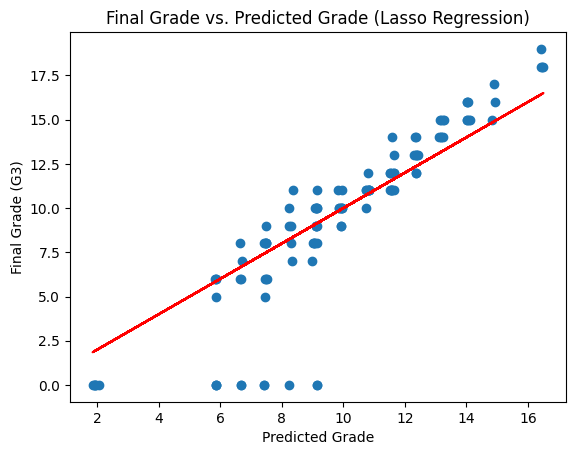

In [12]:
# Prediction and visualization (optional)
predictions = model.predict(X_test)
plt.scatter(predictions, y_test)  # Replace 'studytime' with the desired feature

        # Add labels and title
plt.xlabel('Predicted Grade')
plt.ylabel('Final Grade (G3)')
plt.title(f'Final Grade vs. Predicted Grade ({name})')

        # Add a trendline (optional)
plt.plot(predictions, predictions, color='red')

In [13]:
plt.show()

In [19]:
print("\n🎓 Predict your final grade (G3) using the Ensemble Model (Linear + Lasso)")
try:
    # Collect only the features used for training
    G1 = int(input("Enter G1 (first period grade, 0–20): "))
    G2 = int(input("Enter G2 (second period grade, 0–20): "))
    studytime = int(input("Enter weekly study time (1–4): "))
    failures = int(input("Enter number of past class failures (0–3, else 4): "))
    absences = int(input("Enter number of absences (0–93): "))

    # Constraint checks
    assert 0 <= G1 <= 20
    assert 0 <= G2 <= 20
    assert 1 <= studytime <= 4
    failures = failures if failures < 4 else 4
    assert 0 <= absences <= 93

    # Prepare DataFrame for prediction (RAW input)
    input_data = pd.DataFrame([{
        "G1": G1,
        "G2": G2,
        "studytime": studytime,
        "failures": failures,
        "absences": absences
    }])

    # Scale ONLY the required features (ONCE)
    features_to_normalize = ["failures", "G1", "G2", "absences"]
    input_data_scaled = input_data.copy()
    input_data_scaled[features_to_normalize] = scaler.transform(
        input_data_scaled[features_to_normalize]
    )

    # Predictions from both models
    pred_linear = linear_model.predict(input_data_scaled)[0]
    pred_lasso = lasso_model.predict(input_data_scaled)[0]

    # Final ensemble prediction (average)
    predicted_grade = (pred_linear + pred_lasso) / 2

    print(f"\n🎯 Predicted Final Grade (G3): {predicted_grade:.2f}")

except Exception as e:
    print(f"\n❌ Error: {e}")



🎓 Predict your final grade (G3) using the Ensemble Model (Linear + Lasso)

🎯 Predicted Final Grade (G3): 17.25


In [20]:
# ==============================
# WHAT-IF SIMULATION OUTPUT CELL
# ==============================

# Example student input (can later be replaced by Streamlit UI)
student_input = {
    "G1": 12,
    "G2": 13,
    "studytime": 2,
    "failures": 1,
    "absences": 15
}

# Run what-if analysis
baseline_grade, what_if_results = run_what_if_analysis(
    student_input,
    linear_model,   # trained model from Cell 1
    scaler          # trained scaler from Cell 1
)

# ---- PRINT OUTPUT ----
print("🎓 BASELINE PREDICTION")
print(f"Predicted Final Grade (G3): {baseline_grade}")
print("\n📊 WHAT-IF SIMULATION RESULTS")

for r in what_if_results:
    sign = "+" if r["improvement"] >= 0 else ""
    print(f"- {r['scenario']} → {sign}{r['improvement']} points "
          f"(New Grade: {r['new_predicted_grade']})")


🎓 BASELINE PREDICTION
Predicted Final Grade (G3): 12.97

📊 WHAT-IF SIMULATION RESULTS
- Absences reduced by 5 → -0.18 points (New Grade: 12.78)
- Absences reduced by 10 → -0.37 points (New Grade: 12.6)
- Study time increased by 1 level → -0.09 points (New Grade: 12.87)
- G2 improved by 3 points → +2.98 points (New Grade: 15.94)
- G2 improved by 5 points → +4.96 points (New Grade: 17.93)


In [15]:
import joblib
joblib.dump(linear_model, 'grade_predictor_model.pkl')
joblib.dump(scaler, 'scaler.pkl')  # Save your MinMaxScaler too


['scaler.pkl']